In [ ]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

df = pd.read_csv("dataset/Crop_recommendation.csv")

print("="*50)
print("Dataset Shape :", df.shape)
print("="*50)



Dataset Shape : (2200, 8)


In [ ]:
X = df.drop("label", axis=1)
y = df["label"]

encoder = LabelEncoder()
y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



In [ ]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)



In [ ]:
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

In [ ]:
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("="*60)
print("ACCURACY")
print("="*60)
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")

if train_acc - test_acc > 0.03:
    print("\n⚠ Model kemungkinan mengalami overfitting")
else:
    print("\n✅ Model cukup stabil")



ACCURACY
Train Accuracy : 1.0000
Test Accuracy  : 0.9932

✅ Model cukup stabil


In [ ]:
precision = precision_score(
    y_test,
    test_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    test_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    test_pred,
    average="weighted"
)

print("\n" + "="*60)
print("METRICS")
print("="*60)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")




METRICS
Precision : 0.9935
Recall    : 0.9932
F1 Score  : 0.9932


In [ ]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(classification_report(
    y_test,
    test_pred,
    target_names=encoder.classes_
))




CLASSIFICATION REPORT
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
    

In [ ]:
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("\n" + "="*60)
print("CROSS VALIDATION")
print("="*60)

print("Fold Accuracy :", cv_scores)
print(f"Mean Accuracy : {cv_scores.mean():.4f}")
print(f"Std Dev       : {cv_scores.std():.4f}")




CROSS VALIDATION
Fold Accuracy : [0.99772727 0.99318182 0.99545455 0.99545455 0.99090909]
Mean Accuracy : 0.9945
Std Dev       : 0.0023


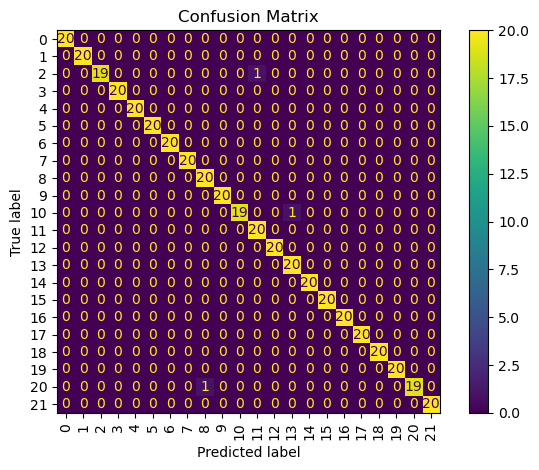

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    xticks_rotation=90
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()




FEATURE IMPORTANCE
       Feature  Importance
6     rainfall    0.223032
4     humidity    0.216081
2            K    0.178776
1            P    0.152931
0            N    0.104542
3  temperature    0.073052
5           ph    0.051586


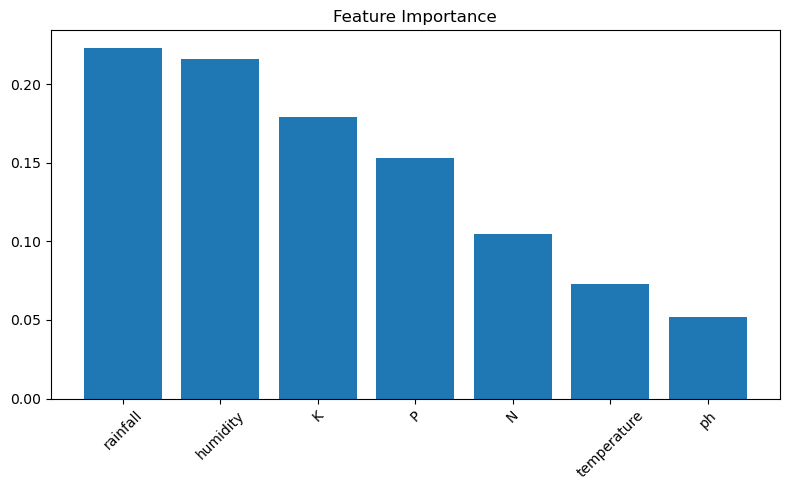

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

print(importance)

plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
joblib.dump(model, "crop_model.pkl")
joblib.dump(encoder, "label_encoder.pkl")

print("\n✅ Model berhasil disimpan!")


✅ Model berhasil disimpan!
